In [9]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [ ]:
# Testing: Calculates the center of the traffic light bounds for frame 0
csv_path = pd.read_csv("bbox_light.csv")

row = csv_path.iloc[0]

u = int((row["x1"] + row["x2"]) / 2)
v = int((row["y1"] + row["y2"]) / 2)

print(f"Pixel of frame {row['frame']}: ({u}, {v})")

# Testing: find cooresponding coordinates for frame 0
data = np.load("xyz_all/depth000000.npz")
print(data.files)

xyz = data["xyz"]
point = xyz[v, u]

X = point[0]
Y = point[1]
Z = point[2]

print(point)
print("X =", X)
print("Y =", Y)
print("Z =", Z)

Skipping Frame 3
Skipping Frame 4
Skipping Frame 5
Skipping Frame 23
Pixel of frame 298: (1046, 100)
['xyz']
[nan nan nan nan]
X = nan
Y = nan
Z = nan


In [19]:
coords = []

files = os.listdir("xyz_all")
files.sort()

for i in range(len(csv_path)):

    row = csv_path.iloc[i]

    if row["x1"] == 0 and row["y1"] == 0 and row["x2"] == 0 and row["y2"] == 0:
        print("Skipping Frame", i)
        continue

    u = int((row["x1"] + row["x2"]) / 2)
    v = int((row["y1"] + row["y2"]) / 2)

    filename = files[i]

    data = np.load("xyz_all/" + filename)

    xyz = data["xyz"]

    point = xyz[v, u]

    X = point[0]
    Y = point[1]
    Z = point[2]

    if np.isnan(X) or np.isnan(Y) or np.isnan(Z):
        print("Skipping Frame", i)
        continue

    coords.append([i, X, Y, Z])

    print("Frame:", i)
    print("File:", filename)
    print("X =", X)
    print("Y =", Y)
    print("Z =", Z)
    print()

Frame: 0
File: depth000000.npz
X = 36.010044
Y = 15.455601
Z = 3.791963

Frame: 1
File: depth000001.npz
X = 35.344994
Y = 15.197862
Z = 3.7219312

Frame: 2
File: depth000002.npz
X = 35.717148
Y = 15.3858795
Z = 3.7611198

Skipping Frame 3
Skipping Frame 4
Skipping Frame 5
Frame: 6
File: depth000006.npz
X = 34.555145
Y = 15.074917
Z = 3.7200122

Frame: 7
File: depth000007.npz
X = 34.524174
Y = 15.088467
Z = 3.716678

Frame: 8
File: depth000008.npz
X = 36.289543
Y = 15.888449
Z = 3.9067278

Frame: 9
File: depth000009.npz
X = 36.12401
Y = 15.844288
Z = 3.8889072

Frame: 10
File: depth000010.npz
X = 34.480022
Y = 15.204299
Z = 3.684899

Frame: 11
File: depth000011.npz
X = 33.88343
Y = 14.967785
Z = 3.6476994

Frame: 12
File: depth000012.npz
X = 34.472168
Y = 15.281896
Z = 3.7380989

Frame: 13
File: depth000013.npz
X = 35.001984
Y = 15.516768
Z = 3.8229864

Frame: 14
File: depth000014.npz
X = 35.68969
Y = 15.877584
Z = 3.8701246

Frame: 15
File: depth000015.npz
X = 33.638954
Y = 15.017989
Z

In [12]:
# Bird's eye view; car's position relative to traffic light using traffic light as the world origin
coords_updated = []

for i in range(len(coords)):

    frame_number = coords[i][0]
    X = coords[i][1]
    Y = coords[i][2]
    Z = coords[i][3]

    car_X = -X
    car_Y = -Y

    coords_updated.append([frame_number, car_X, car_Y, Z])

    print("Frame:", frame_number)
    print("Car X =", car_X)
    print("Car Y =", car_Y)
    print("Z =", Z)
    print()

Frame: 0
Car X = -36.010044
Car Y = -15.455601
Z = 3.791963

Frame: 1
Car X = -35.344994
Car Y = -15.197862
Z = 3.7219312

Frame: 2
Car X = -35.717148
Car Y = -15.3858795
Z = 3.7611198

Frame: 6
Car X = -34.555145
Car Y = -15.074917
Z = 3.7200122

Frame: 7
Car X = -34.524174
Car Y = -15.088467
Z = 3.716678

Frame: 8
Car X = -36.289543
Car Y = -15.888449
Z = 3.9067278

Frame: 9
Car X = -36.12401
Car Y = -15.844288
Z = 3.8889072

Frame: 10
Car X = -34.480022
Car Y = -15.204299
Z = 3.684899

Frame: 11
Car X = -33.88343
Car Y = -14.967785
Z = 3.6476994

Frame: 12
Car X = -34.472168
Car Y = -15.281896
Z = 3.7380989

Frame: 13
Car X = -35.001984
Car Y = -15.516768
Z = 3.8229864

Frame: 14
Car X = -35.68969
Car Y = -15.877584
Z = 3.8701246

Frame: 15
Car X = -33.638954
Car Y = -15.017989
Z = 3.6741135

Frame: 16
Car X = -33.36852
Car Y = -14.923409
Z = 3.6707306

Frame: 17
Car X = -33.725235
Car Y = -15.135812
Z = 3.7099714

Frame: 18
Car X = -33.86427
Car Y = -15.224753
Z = 3.7783527

Frame:

In [13]:
# Aligning with the +X axis
world_coords = []

initial_X = coords[0][1]
initial_Y = coords[0][2]

angle = np.arctan2(initial_Y, initial_X)

for i in range(len(coords_updated)):

    frame_number = coords_updated[i][0]
    car_X = coords_updated[i][1]
    car_Y = coords_updated[i][2]

    world_X = car_X * np.cos(angle) + car_Y * np.sin(angle)
    world_Y = -car_X * np.sin(angle) + car_Y * np.cos(angle)
    world_coords.append([frame_number, world_X, world_Y])

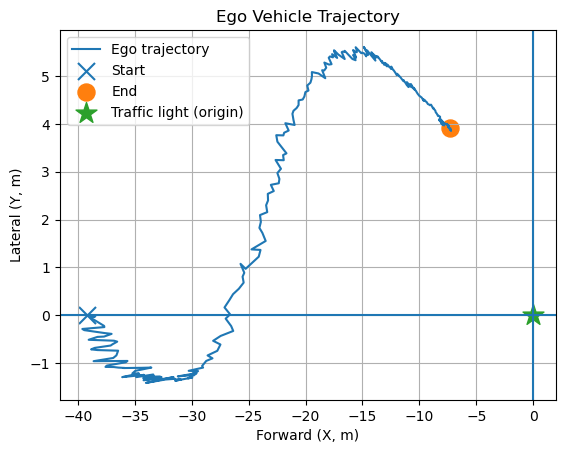

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot
x_coords = []
y_coords = []

for i in range(len(world_coords)):

    world_X = world_coords[i][1]
    world_Y = world_coords[i][2]

    x_coords.append(world_X)
    y_coords.append(world_Y)

# Plot the entire car trajectory
plt.plot(
    x_coords,
    y_coords,
    label="Ego trajectory"
)

# Plot the starting position of the car
start_X = x_coords[0]
start_Y = y_coords[0]

plt.scatter(
    start_X,
    start_Y,
    marker="x",
    s=150,
    label="Start"
)

# Plot the ending position of the car
end_X = x_coords[len(x_coords) - 1]
end_Y = y_coords[len(y_coords) - 1]

plt.scatter(
    end_X,
    end_Y,
    s=150,
    label="End"
)

# Plot the traffic light at the world origin
traffic_light_X = 0
traffic_light_Y = 0

plt.scatter(
    traffic_light_X,
    traffic_light_Y,
    marker="*",
    s=250,
    label="Traffic light (origin)"
)

# Add labels and title
plt.axhline(y=0)
plt.axvline(x=0)
plt.xlabel("Forward (X, m)")
plt.ylabel("Lateral (Y, m)")
plt.title("Ego Vehicle Trajectory")
plt.grid()
plt.legend()

plt.savefig("trajectory.png")
plt.show()

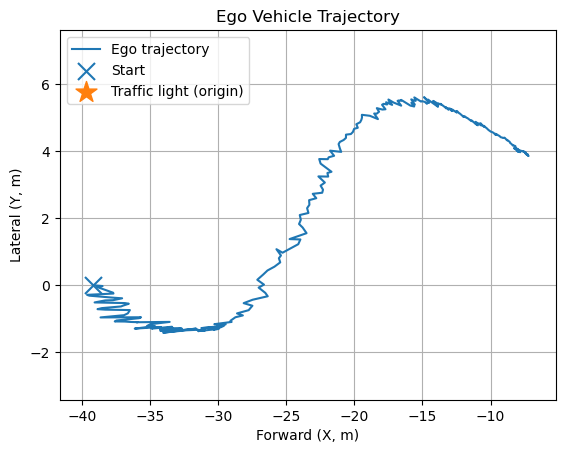

In [ ]:
from matplotlib.animation import FuncAnimation

# Create the figure and axes
figure, axis = plt.subplots()

# Create an empty line for the trajectory
trajectory_line, = axis.plot(
    [],
    [],
    label="Ego trajectory"
)

# Plot the starting point
start_point = axis.scatter(
    x_coords[0],
    y_coords[0],
    marker="x",
    s=150,
    label="Start"
)

# Plot the traffic light at the origin
traffic_light = axis.scatter(
    0,
    0,
    marker="*",
    s=250,
    label="Traffic light (origin)"
)

# Set axis labels
axis.set_xlabel("Forward (X, m)")
axis.set_ylabel("Lateral (Y, m)")
axis.set_title("Ego Vehicle Trajectory")
axis.grid()
axis.legend()

# Set the axis limits
axis.set_xlim(
    min(x_coords) - 2,
    max(x_coords) + 2
)

axis.set_ylim(
    min(y_coords) - 2,
    max(y_coords) + 2
)

def update(frame_number):

    current_x = x_coords[0:frame_number + 1]
    current_y = y_coords[0:frame_number + 1]

    trajectory_line.set_data(
        current_x,
        current_y
    )

    return trajectory_line,

animation = FuncAnimation(
    figure,
    update,
    frames=len(x_coords),
    interval=50
)

animation.save(
    "trajectory.mp4",
    writer="ffmpeg",
    fps=40
)

plt.show()